In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress
import pandas as pd

In [2]:
def sample_power_law(xmin_spl,xmax_spl,b_spl,distribution_spl):
    
    """ This function samples particle size following power law distibution """
    
    exponent = b_spl + 1
    norm = (xmax_spl**exponent - xmin_spl**exponent)
    MP_size = (distribution_spl * norm + xmin_spl**exponent) ** (1 / exponent)
    return MP_size

In [3]:
def simulated_sampling(xmin_ss, xmax_ss, LOD_min_ss,LOD_max_ss, b_ss, samples_ss):
    
    """ Returns the distribution of MP sizes within the LOD interval sampled from MP 1-5000 distribution. """
    
    part_total = sample_power_law(xmin_ss, xmax_ss, b_ss, samples_ss)
    part_dispo = part_total[(part_total > LOD_min_ss) & (part_total < LOD_max_ss)]

    if len(part_dispo) == 0:
        print('Problem: there are no particles in the LOD range',LOD_min_ss,LOD_max_ss)
        return np.array([]) 

    size_distribution = np.sort(part_dispo)

    return size_distribution

def slope_comparison_after_binning(bin_edges_sc, size_distribution_sc,  slope_theoric_sc):
    
    """ This function bins sampled particles into equisized bins = bins_edges_sc, and normalises the bins by dividing by the binsize.
    It computes a new slope based on linear distibution in a log-log scale. Bins with zero particles are not taken in account.
    Returns slope, intercept and slope difference between calculated slope out of log-log scale linear regression and original slope. 
    
    bin_edges_sc: multi-dimentinal array with edges of the bins for every chosen bin size"""
    
    particle_counts = []
    mean_length = []
    bin_size = []
    bins = []
    
    # Divide particles in the bins 
    for i in range(len(bin_edges_sc) - 1):
        lower = bin_edges_sc[i]
        upper = bin_edges_sc[i + 1]
    
        # Distibute particles in the current bin 
        bin_particles = size_distribution_sc[(size_distribution_sc > lower) & (size_distribution_sc <= upper)]
    
        particle_counts.append(len(bin_particles))
        mean_length.append((lower + upper) / 2)
        bin_size.append(upper-lower) 
        bins.append(bin_particles)

    # Arrays out of lists    
    particle_counts_arr = np.array(particle_counts)
    bin_size_arr = np.array(bin_size)
    mean_length_arr = np.array(mean_length)
    
    # Normalizing the counts and putting into log-log scale
    valid = particle_counts_arr > 0
    log_mean_size = np.log10(mean_length_arr[valid])
    normalized_counts = particle_counts_arr[valid] / bin_size_arr[valid]
    log_normalized_counts = np.log10(normalized_counts)

    # Slope and intercept 
    slope = linregress(log_mean_size, log_normalized_counts).slope
    intercept = linregress(log_mean_size, log_normalized_counts).intercept
    N = (10**intercept/(1+slope))*(5000**(1+slope)-1**(1+slope))


    # Compute the difference of the slope after binning with the original slope
    slope_difference = np.absolute(slope_theoric_sc - slope)
    slope_difference_pourcentage = np.absolute(slope_theoric_sc - slope)*100/np.absolute(slope_theoric_sc)

    return slope, slope_difference, N 
    

In [4]:
#slope
slope_th = -2.

# MP range
xmin = 1
xmax = 5000

# Physical limits of detection
LOD_low = 10
LOD_high = 4500

# Sampling                    
sampling_campaigns = 100                         
number_of_particles_full_range = np.arange(500,50501,500)  

# Multiple sampling campaigns
n_sampled=[]
all_samplings_particles=[]
for j in range(len(number_of_particles_full_range)):
    all_samplings=[]
    number_of_particles=[]
    for i in range(sampling_campaigns):
        random_sequence = np.random.uniform(0, 1, number_of_particles_full_range[j])
        size_distribution=simulated_sampling(xmin_ss=xmin, xmax_ss=xmax, LOD_min_ss=LOD_low,
                                                LOD_max_ss=LOD_high, b_ss=slope_th, samples_ss=random_sequence)
        all_samplings.append(size_distribution)
        number_of_particles.append(len(size_distribution))
    all_samplings_particles.append(all_samplings)
    n_sampled.append(np.mean(number_of_particles))
    

In [5]:

# Irregular bins
initial_step = 5
irregular_bins=[]
step = initial_step
current_edge = LOD_low
edges = [current_edge]

while True:
    next_step = step
    current_edge += next_step
    if current_edge > LOD_high:
        break
    edges.append(current_edge)
    step *= 2  # next step doubles
irregular_bins = edges
irregular_bins.append(LOD_high)
lower=[]
upper=[]
for i in range(len(irregular_bins) - 1):
    lower.append(irregular_bins[i])
    upper.append(irregular_bins[i + 1])
lower=np.array(lower)
upper=np.array(upper)

mean_length=((lower + upper) / 2)
bin_size=(upper-lower)

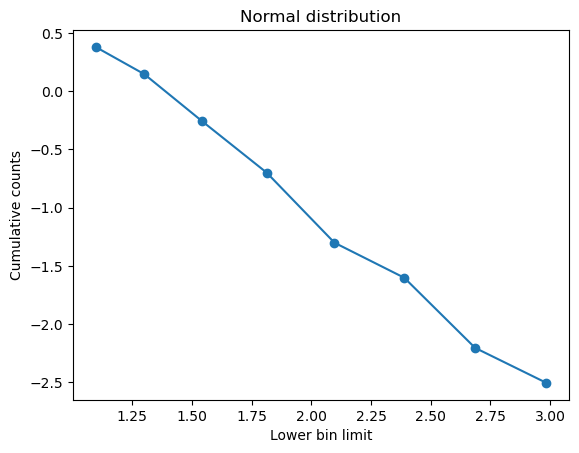

In [6]:
lower_bin_limits = irregular_bins
slope_err_mean=[]
N_mean=[]
for j in range(len(number_of_particles_full_range)):
    slope_err_=[]
    N_=[]
    for i in range(sampling_campaigns):
        particle_counts=[]
        bins=[]
        for k in range(len(lower_bin_limits) - 1):
    
        # Distibute particles in the current bin 
            bin_particles = all_samplings_particles[j][i][(all_samplings_particles[j][i] > lower[k]) & (all_samplings_particles[j][i] <= upper[k])]
            particle_counts.append(len(bin_particles))
            bins.append(bin_particles)
        # Arrays out of lists    
        particle_counts_arr = np.array(particle_counts)
    
    # Normalizing the counts and putting into log-log scale
        valid = particle_counts_arr > 0
        log_mean_size = np.log10(mean_length[valid])
        normalized_counts = particle_counts_arr[valid] / bin_size[valid]
        log_normalized_counts = np.log10(normalized_counts)

            # Slope and intercept 
        slope, intercept, *_ = linregress(log_mean_size, log_normalized_counts)
        N = (10**intercept/(1+slope))*(5000**(1+slope)-1**(1+slope))
        slope_difference = np.absolute(slope_th - slope)
        
        if i == 0 and j==0:

            plt.plot(log_mean_size, log_normalized_counts, marker='o')
            plt.xlabel('Lower bin limit')
            plt.ylabel("Cumulative counts")
            plt.title('Normal distribution')
            
        slope_err_.append(slope_difference)
        N_.append(N)     
    slope_err_mean.append(np.mean(slope_err_))
    N_mean.append(np.mean(N_))
   
    

In [7]:
tableau_recapitulatif_particles = pd.DataFrame({
    'Initial number of particles': number_of_particles_full_range,
    'Calculated number of particles': N_mean,
    '% error': np.absolute(number_of_particles_full_range-np.absolute(N_mean))*100/number_of_particles_full_range,
    'Number of sampled particles':n_sampled,
    'Error on slope': slope_err_mean
})

In [8]:
tableau_recapitulatif_particles

,Initial number of particles,Calculated number of particles,% error,Number of sampled particles,Error on slope
0,500,350.912199,29.817560,50.06,0.229413
1,1000,793.342069,20.665793,99.13,0.146797
2,1500,1220.961045,18.602597,150.66,0.131152
3,2000,1729.121033,13.543948,198.21,0.100707
4,2500,2322.778729,7.088851,250.15,0.083079
...,...,...,...,...,...
96,48500,53471.281233,10.250064,4839.85,0.030088
97,49000,54518.830986,11.262920,4895.40,0.029665
98,49500,54359.003817,9.816169,4935.65,0.032257
99,50000,54287.411314,8.574823,4986.29,0.027926


With parameters: LOD_low= 10 LOD_high= 4500 slope= -2.0


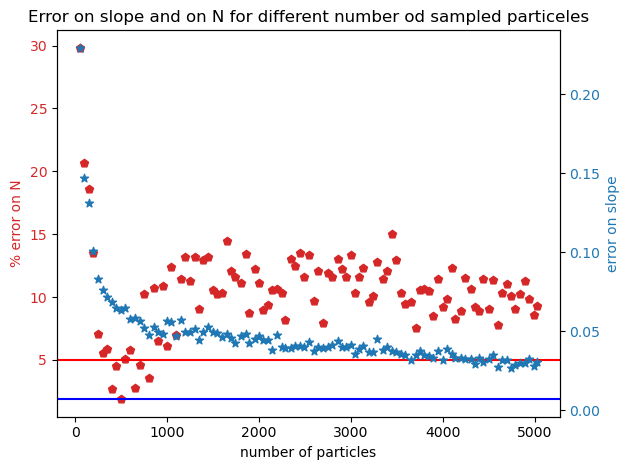

In [9]:
print('With parameters: LOD_low=',LOD_low,'LOD_high=',LOD_high,'slope=',slope_th)

serr=tableau_recapitulatif_particles['Error on slope']
Nerr=tableau_recapitulatif_particles['% error']
fig, ax1 = plt.subplots()

color = 'tab:red'
ax1.set_xlabel('number of particles')
ax1.set_ylabel('% error on N', color=color)
ax1.scatter(tableau_recapitulatif_particles['Number of sampled particles'],Nerr, color=color, marker='p')
ax1.tick_params(axis='y', labelcolor=color)
ax1.axhline(y=5,xmin=0,xmax=5000,color='r')
ax2 = ax1.twinx()  # instantiate a second Axes that shares the same x-axis

color = 'tab:blue'
ax2.set_ylabel('error on slope', color=color)  # we already handled the x-label with ax1
ax2.scatter(tableau_recapitulatif_particles['Number of sampled particles'],serr, color=color, marker='*')
ax2.tick_params(axis='y', labelcolor=color)
ax2.axhline(y=0.007,xmin=0,xmax=5000,color='b')

plt.title('Error on slope and on N for different number od sampled particeles')
fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.show()


### LOD

In [10]:
# Adapted version for slope changes
def simulated_sampling(LOD_min_ss,LOD_max_ss, b_ss, samples_ss):
    
    """ Returns the distribution of MP sizes within the LOD interval sampled from MP 1-5000 distribution. """
    
    #part_total = sample_power_law(xmin_ss, xmax_ss, b_ss, samples_ss)
    #part_dispo = part_total[(part_total > LOD_min_ss) & (part_total < LOD_max_ss)]

    part_dispo = sample_power_law(LOD_min_ss, LOD_max_ss, b_ss, samples_ss)
    
    if len(part_dispo) == 0:
        print('Problem: there are no particles in the LOD range',LOD_min_ss,LOD_max_ss)
        return np.array([]) 

    size_distribution = np.sort(part_dispo)

    return size_distribution
    

In [11]:
#slope
slope_th = -2.

# MP range
xmin = 1
xmax = 5000

# Physical limits of detection
LOD_low = np.arange(10,1010,100)
LOD_high = 4500

# Sampling                    
sampling_campaigns = 100                         
number_of_particles_sampled = 1000  

# Multiple sampling campaigns
n_sampled=[]
all_samplings_lod=[]
for j in range(len(LOD_low)):
    all_samplings=[]
    number_of_particles=[]
    for i in range(sampling_campaigns):
        random_sequence = np.random.uniform(0, 1, number_of_particles_sampled)
        size_distribution=simulated_sampling(LOD_min_ss=LOD_low[j],LOD_max_ss=LOD_high, b_ss=slope_th, samples_ss=random_sequence)
        all_samplings.append(size_distribution)
        number_of_particles.append(len(size_distribution))
    all_samplings_lod.append(all_samplings)
    n_sampled.append(np.mean(number_of_particles))
    

In [12]:
# Irregular bins
all_irregular_bins=[]
for i in range(len(LOD_low)):
    initial_step = 5
    irregular_bins=[]
    step = initial_step
    current_edge = LOD_low[i]
    edges = [current_edge]

    while True:
        next_step = step
        current_edge += next_step
        if current_edge > LOD_high:
            break
        edges.append(current_edge)
        step *= 2  # next step doubles
    irregular_bins = edges
    irregular_bins.append(LOD_high)
    all_irregular_bins.append(irregular_bins)

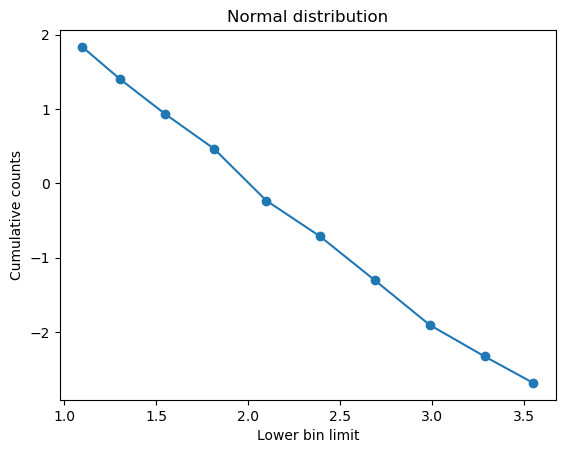

In [13]:
lower_bin_limits = all_irregular_bins
slope_err_mean=[]
N_mean_err=[]
mean_N=[]
for j in range(len(LOD_low)):
    used_bin_limits=lower_bin_limits[j]
    slope_err_=[]
    N_=[]
    for i in range(sampling_campaigns):
        particle_counts=[]
        bins=[]
        mean_length=[]
        bin_size=[]
        for k in range(len(used_bin_limits) - 1):
            lower=used_bin_limits[k]
            upper=used_bin_limits[k+1]


        # Distibute particles in the current bin 
            bin_particles = all_samplings_lod[j][i][(all_samplings_lod[j][i] > lower) & (all_samplings_lod[j][i] <= upper)]
            particle_counts.append(len(bin_particles))
            bins.append(bin_particles)
   
            mean_length.append((lower + upper) / 2)
            bin_size.append(upper-lower) 

        # Arrays out of lists    
        particle_counts_arr = np.array(particle_counts)
        bin_size_arr = np.array(bin_size)
        mean_length_arr = np.array(mean_length)
    
    # Normalizing the counts and putting into log-log scale
        valid = particle_counts_arr > 0
        log_mean_size = np.log10(mean_length_arr[valid])
        normalized_counts = particle_counts_arr[valid] / bin_size_arr[valid]
        log_normalized_counts = np.log10(normalized_counts)

            # Slope and intercept 
        slope, intercept, *_ = linregress(log_mean_size, log_normalized_counts)
        N = (10**intercept/(1+slope))*(5000**(1+slope)-1**(1+slope))
        slope_difference = np.absolute(slope_th - slope)
        
        if i == 0 and j==0:
            plt.plot(log_mean_size, log_normalized_counts, marker='o')
            plt.xlabel('Lower bin limit')
            plt.ylabel("Cumulative counts")
            plt.title('Normal distribution')
            
        slope_err_.append(slope_difference)
        N_.append(N)   
    mean_N.append(np.nanmean(N_))
    slope_err_mean.append(np.nanmean(slope_err_))
    N_mean_err.append(np.nanmean(np.absolute(N_-mean_N[j])))
   

In [14]:
tableau_recapitulatif_particles = pd.DataFrame({
    'LOD_low': LOD_low,
    '% error': np.array(N_mean_err)*100/np.array(mean_N),
    'Number of sampled particles':n_sampled,
    'Error on slope': slope_err_mean
})

With parameters: n = 1000 LOD_high= 4500 slope= -2.0


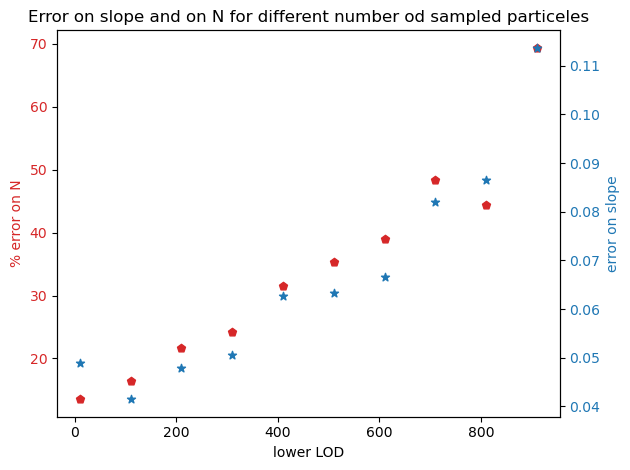

In [15]:
print('With parameters: n =',1000,'LOD_high=',LOD_high,'slope=',slope_th)

serr=tableau_recapitulatif_particles['Error on slope']
Nerr=tableau_recapitulatif_particles['% error']
fig, ax1 = plt.subplots()

color = 'tab:red'
ax1.set_xlabel('lower LOD')
ax1.set_ylabel('% error on N', color=color)
ax1.scatter(tableau_recapitulatif_particles['LOD_low'],Nerr, color=color, marker='p')
ax1.tick_params(axis='y', labelcolor=color)
#ax1.axhline(y=5,xmin=0,xmax=5000,color='r')

ax2 = ax1.twinx()  # instantiate a second Axes that shares the same x-axis

color = 'tab:blue'
ax2.set_ylabel('error on slope', color=color)  # we already handled the x-label with ax1
ax2.scatter(tableau_recapitulatif_particles['LOD_low'],serr, color=color, marker='*')
ax2.tick_params(axis='y', labelcolor=color)
#ax2.axhline(y=0.007,xmin=0,xmax=5000,color='b')

plt.title('Error on slope and on N for different number od sampled particeles')
fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.show()


### slope

In [16]:
#slope
slope_th = np.arange(-3.8,-1.1,0.15)

# MP range
xmin = 1
xmax = 5000

# Physical limits of detection
LOD_low = 10
LOD_high = 4500

# Sampling                    
sampling_campaigns = 100                         
number_of_particles_sampled = 10000     

# Multiple sampling campaigns
n_sampled=[]
all_samplings_slope=[]
for j in range(len(slope_th)):
    all_samplings=[]
    number_of_particles=[]
    for i in range(sampling_campaigns):
        random_sequence = np.random.uniform(0, 1, number_of_particles_sampled)
        size_distribution=simulated_sampling(LOD_min_ss=LOD_low,
                                                LOD_max_ss=LOD_high, b_ss=slope_th[j], samples_ss=random_sequence)
        all_samplings.append(size_distribution)
        number_of_particles.append(len(size_distribution))
    all_samplings_slope.append(all_samplings)
    n_sampled.append(np.mean(number_of_particles))
    

In [17]:
# Irregular bins
all_irregular_bins=[]
for i in range(len(slope_th)):
    initial_step = 5
    irregular_bins=[]
    step = initial_step
    current_edge = LOD_low
    edges = [current_edge]

    while True:
        next_step = step
        current_edge += next_step
        if current_edge > LOD_high:
            break
        edges.append(current_edge)
        step *= 2  # next step doubles
    irregular_bins = edges
    all_irregular_bins.append(irregular_bins)
    

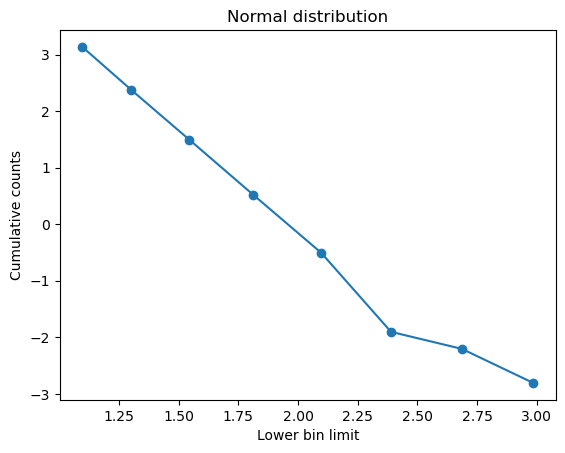

In [18]:
lower_bin_limits = all_irregular_bins
slope_err_mean=[]
N_mean_err=[]
mean_N=[]
for j in range(len(slope_th)):
    used_bin_limits=lower_bin_limits[j]
    slope_err_=[]
    N_=[]
    for i in range(sampling_campaigns):
        particle_counts=[]
        bins=[]
        mean_length=[]
        bin_size=[]
        for k in range(len(used_bin_limits) - 1):
            lower=used_bin_limits[k]
            upper=used_bin_limits[k+1]


        # Distibute particles in the current bin 
            bin_particles = all_samplings_slope[j][i][(all_samplings_slope[j][i] > lower) & (all_samplings_slope[j][i] <= upper)]
            particle_counts.append(len(bin_particles))
            bins.append(bin_particles)
   
            mean_length.append((lower + upper) / 2)
            bin_size.append(upper-lower) 

        # Arrays out of lists    
        particle_counts_arr = np.array(particle_counts)
        bin_size_arr = np.array(bin_size)
        mean_length_arr = np.array(mean_length)
    
    # Normalizing the counts and putting into log-log scale
        valid = particle_counts_arr > 0
        log_mean_size = np.log10(mean_length_arr[valid])
        normalized_counts = particle_counts_arr[valid] / bin_size_arr[valid]
        log_normalized_counts = np.log10(normalized_counts)

            # Slope and intercept 
        slope, intercept, *_ = linregress(log_mean_size, log_normalized_counts)
        N = (10**intercept/(1+slope))*(5000**(1+slope)-1**(1+slope))
        slope_difference = np.absolute(slope_th[j] - slope)
        
        if i == 0 and j==0:
            plt.plot(log_mean_size, log_normalized_counts, marker='o')
            plt.xlabel('Lower bin limit')
            plt.ylabel("Cumulative counts")
            plt.title('Normal distribution')
            
        slope_err_.append(slope_difference)
        N_.append(N)   
    mean_N.append(np.nanmean(N_))
    slope_err_mean.append(np.nanmean(slope_err_))
    N_mean_err.append(np.nanmean(np.absolute(N_-mean_N[j])))
    

In [19]:
tableau_recapitulatif_particles = pd.DataFrame({
    'slope': slope_th,
    '% error': np.array(N_mean_err)*100/np.array(mean_N),
    'Number of sampled particles':n_sampled,
    'Error on slope': slope_err_mean
})

With parameters: n = 10000 LOD_high= 4500 LOD_low= 10


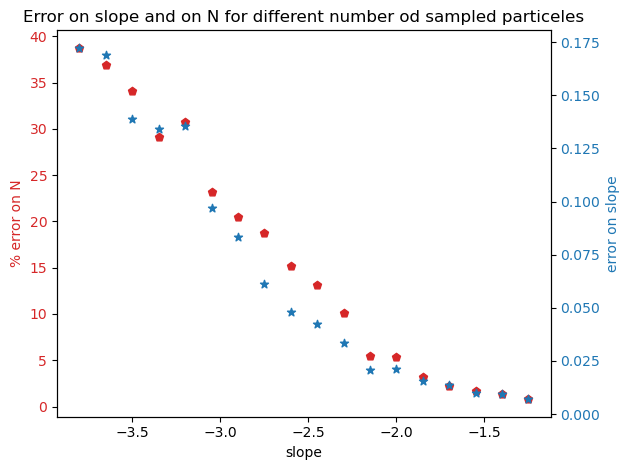

In [20]:
print('With parameters: n =',10000,'LOD_high=',LOD_high,'LOD_low=',LOD_low)

serr=tableau_recapitulatif_particles['Error on slope']
Nerr=tableau_recapitulatif_particles['% error']
fig, ax1 = plt.subplots()

color = 'tab:red'
ax1.set_xlabel('slope')
ax1.set_ylabel('% error on N', color=color)
ax1.scatter(tableau_recapitulatif_particles['slope'],Nerr, color=color, marker='p')
ax1.tick_params(axis='y', labelcolor=color)
#ax1.axhline(y=5,xmin=0,xmax=5000,color='r')

ax2 = ax1.twinx()  # instantiate a second Axes that shares the same x-axis

color = 'tab:blue'
ax2.set_ylabel('error on slope', color=color)  # we already handled the x-label with ax1
ax2.scatter(tableau_recapitulatif_particles['slope'],serr, color=color, marker='*')
ax2.tick_params(axis='y', labelcolor=color)
#ax2.axhline(y=0.007,xmin=0,xmax=5000,color='b')

plt.title('Error on slope and on N for different number od sampled particeles')
fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.show()